# Step 4 - Exploratory Data Analysis (EDA)

Goal:
- Build a production-style EDA workflow for Lending Club credit risk data.
- Keep Spark as the primary compute engine and collect only aggregated results to pandas/matplotlib.

Scope:
1. Basic data analysis
2. Missing value analysis
3. Numerical variable analysis
4. Categorical variable analysis
5. Correlation analysis
6. Time series analysis
7. Risk analysis
8. Executive summary

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pyspark": "pyspark"
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    print("Package installation completed.")
else:
    print("All core EDA packages are already installed.")

All core EDA packages are already installed.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel
from pyspark.ml.feature import VectorAssembler, Bucketizer
from pyspark.ml.stat import Correlation

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
sns.set_palette("tab10")

In [3]:
from pyspark import SparkContext

APP_NAME = "CreditRisk-Step4-EDA"
WORKSPACE_ROOT = "c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main"

def _reset_pyspark_runtime_state():
    # Clear stale JVM/gateway handles after a crashed Spark driver.
    try:
        SparkContext._active_spark_context = None
        SparkContext._gateway = None
        SparkContext._jvm = None
    except Exception:
        pass
    try:
        SparkSession._instantiatedSession = None
        SparkSession._activeSession = None
    except Exception:
        pass

def _build_spark_session():
    _reset_pyspark_runtime_state()
    return (
        SparkSession.builder
        .master("local[*]")
        .appName(APP_NAME)
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.shuffle.partitions", "200")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .config("spark.sql.ansi.enabled", "false")
        .config("spark.driver.memory", "4g")
        .config("spark.driver.maxResultSize", "1g")
        .getOrCreate()
    )

def ensure_live_spark(existing_spark=None):
    if existing_spark is not None:
        try:
            existing_spark.range(1).count()
            return existing_spark
        except Exception:
            try:
                existing_spark.stop()
            except Exception:
                pass

    try:
        active_sc = SparkContext._active_spark_context
        if active_sc is not None:
            active_sc.stop()
    except Exception:
        pass

    _reset_pyspark_runtime_state()
    return _build_spark_session()

spark = ensure_live_spark(globals().get("spark"))
spark.conf.set("spark.sql.ansi.enabled", "false")
spark.sparkContext.setLogLevel("WARN")

def hdfs_path_exists(path: str) -> bool:
    if not path:
        return False
    try:
        jvm = spark._jvm
        fs = jvm.org.apache.hadoop.fs.FileSystem.get(spark._jsc.hadoopConfiguration())
        return bool(fs.exists(jvm.org.apache.hadoop.fs.Path(path)))
    except Exception:
        return os.path.exists(path)

def first_existing_path(candidates):
    for p in candidates:
        if p and hdfs_path_exists(p):
            return p
    return None

RAW_CSV_CANDIDATES = [
    f"{WORKSPACE_ROOT}/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "/app/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "../data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv"
]

GOOD_STATUSES = ["Fully Paid"]
BAD_STATUSES = ["Charged Off", "Default", "Late (31-120 days)"]
DROP_STATUSES = [
    "Current",
    "Issued",
    "In Grace Period",
    "Late (16-30 days)"
]
TARGET_COL = "target"

In [4]:
try:
    spark.range(1).count()
except Exception:
    spark = ensure_live_spark(None)

raw_path = first_existing_path(RAW_CSV_CANDIDATES)
if raw_path is None:
    raise FileNotFoundError("Lending Club CSV file was not found in expected paths.")

raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .csv(raw_path)
)

def parse_percent(col_name):
    safe_col = f"`{col_name}`"
    return F.expr(
        f"try_cast(regexp_extract(trim(cast({safe_col} as string)), '^([+-]?\\\\d+(?:\\\\.\\\\d+)?)%?$', 1) as double)"
    )

df = (
    raw_df
    .withColumn("int_rate_num", parse_percent("int_rate"))
    .withColumn("revol_util_num", parse_percent("revol_util"))
    .withColumn(
        TARGET_COL,
        F.when(F.col("loan_status").isin(BAD_STATUSES), F.lit(1))
         .when(F.col("loan_status").isin(GOOD_STATUSES), F.lit(0))
         .otherwise(F.lit(None).cast("int"))
    )
)

analysis_df = df.filter(F.col(TARGET_COL).isNotNull()).persist(StorageLevel.DISK_ONLY)
analysis_count = analysis_df.count()

print(f"Resolved raw data path: {raw_path}")
print(f"Rows after target filtering (GOOD/BAD only): {analysis_count:,}")
print(f"Columns available: {len(analysis_df.columns)}")

Resolved raw data path: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
Rows after target filtering (GOOD/BAD only): 1,366,816
Columns available: 154


## 1) Basic Data Analysis

This section covers:
- total row/column counts
- schema and data types
- approximate unique values
- `loan_status` distribution
- binary target distribution and imbalance
- `describe()` outputs

In [5]:
total_rows_raw = raw_df.count()
total_cols_raw = len(raw_df.columns)

print(f"Total rows (raw): {total_rows_raw:,}")
print(f"Total columns (raw): {total_cols_raw}")
print("\nSpark DataFrame schema:")
raw_df.printSchema()

dtype_pdf = pd.DataFrame(raw_df.dtypes, columns=["column", "spark_type"])
print("\nData types (first 40 rows):")
print(dtype_pdf.head(40).to_string(index=False))

approx_unique = raw_df.select([F.approx_count_distinct(F.col(c)).alias(c) for c in raw_df.columns]).first().asDict()
approx_unique_pdf = pd.DataFrame({
    "column": list(approx_unique.keys()),
    "approx_unique_values": list(approx_unique.values())
}).sort_values("approx_unique_values", ascending=False)
print("\nApproximate unique counts (top 40 columns):")
print(approx_unique_pdf.head(40).to_string(index=False))

print("\nloan_status distribution:")
loan_status_dist_df = raw_df.groupBy("loan_status").count().orderBy(F.desc("count"))
loan_status_dist_df.show(50, truncate=False)

print("Binary target distribution (0=GOOD, 1=BAD):")
target_dist_df = analysis_df.groupBy(TARGET_COL).count().orderBy(TARGET_COL)
target_dist_df.show()

counts_dict = {int(row[TARGET_COL]): int(row["count"]) for row in target_dist_df.collect()}
good_n = counts_dict.get(0, 0)
bad_n = counts_dict.get(1, 0)
imbalance_ratio = (good_n / bad_n) if bad_n else np.nan
bad_rate = (bad_n / (good_n + bad_n)) if (good_n + bad_n) else np.nan

print(f"Class imbalance (GOOD/BAD): {imbalance_ratio:.2f}")
print(f"Bad loan ratio: {bad_rate:.2%}")

print("\nRaw describe() output:")
raw_df.describe().show(30, truncate=False)

focus_describe_cols = [
    "loan_amnt", "int_rate_num", "annual_inc", "dti",
    "fico_range_high", "revol_util_num", "installment", TARGET_COL
]
available_focus_cols = [c for c in focus_describe_cols if c in analysis_df.columns]
print("Focused numerical describe() output:")
analysis_df.select(*available_focus_cols).describe().show(truncate=False)

Total rows (raw): 2,260,701
Total columns (raw): 151

Spark DataFrame schema:
root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: string

Interpretation guide:
- If `GOOD/BAD` ratio is high, class imbalance handling is required before training.
- Very high unique cardinality columns (for example IDs) should not be directly encoded.
- `describe()` outputs reveal scale mismatch and potential outlier sensitivity for model selection.

## 2) Missing Value Analysis

This section computes missing counts/percentages for every column, highlights high-missing columns, and visualizes the result.

Rows considered for missing analysis: 1,366,816
                                    column  missing_count  missing_pct
                                 member_id        1366816   100.000000
orig_projected_additional_accrued_interest        1361606    99.618822
            hardship_payoff_balance_amount        1359436    99.460059
              hardship_last_payment_amount        1359436    99.460059
                              hardship_dpd        1359432    99.459766
                      hardship_loan_status        1359430    99.459620
                       hardship_start_date        1359429    99.459547
                         hardship_end_date        1359428    99.459474
                           hardship_length        1359427    99.459401
                   payment_plan_start_date        1359425    99.459254
                           hardship_amount        1359422    99.459035
                             deferral_term        1359414    99.458449
                           ha

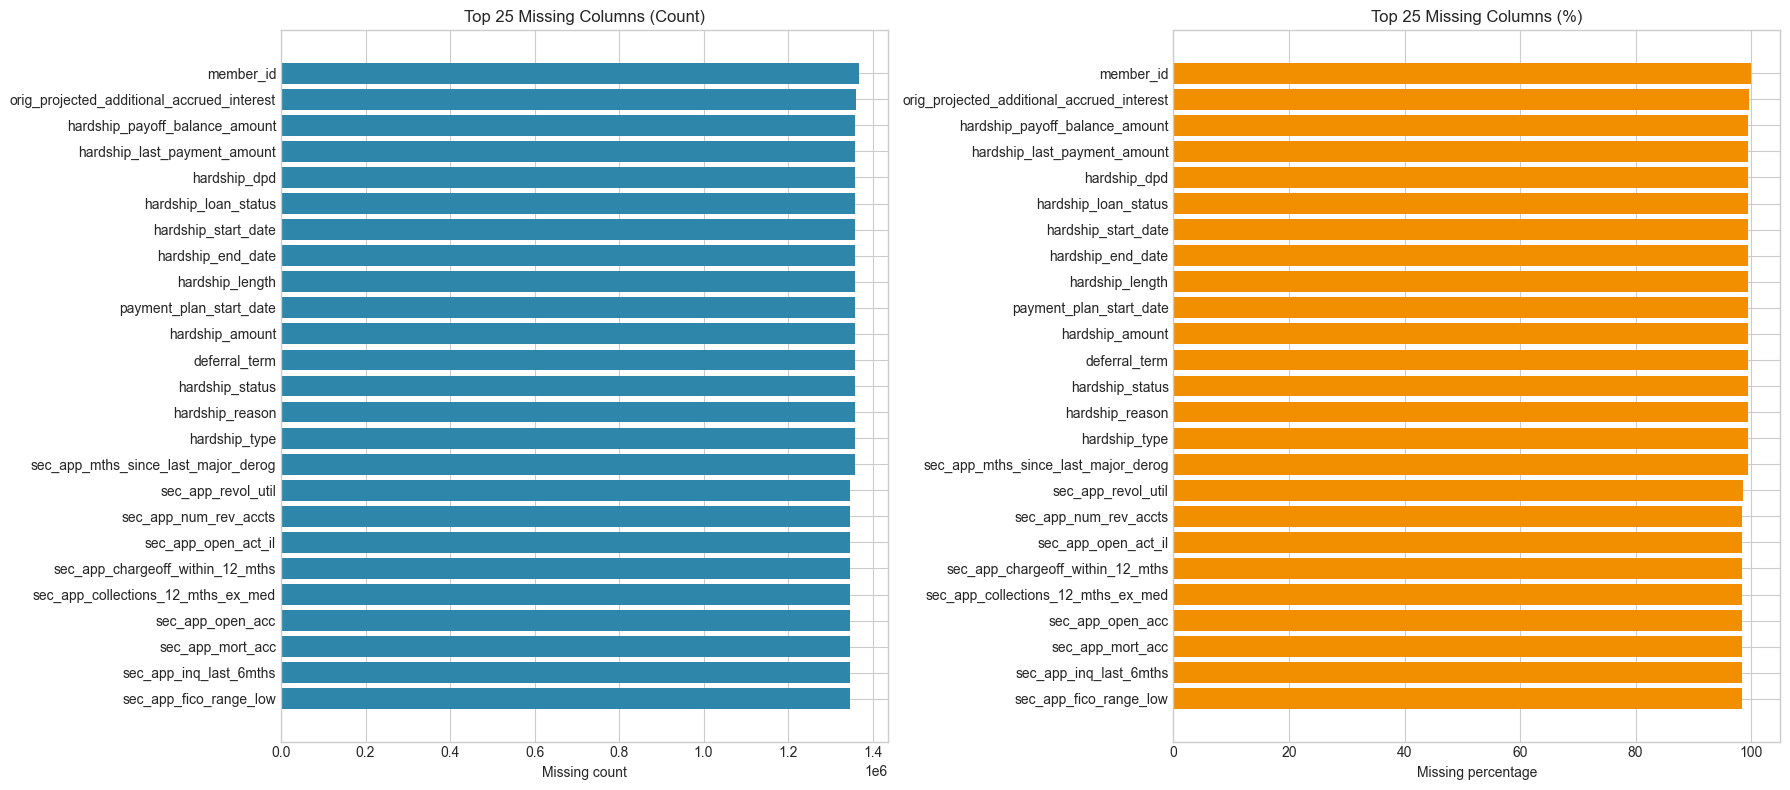

In [6]:
def missing_table(df_input):
    total = df_input.count()
    missing_exprs = [
        F.sum(
            F.when(
                F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""),
                F.lit(1)
            ).otherwise(F.lit(0))
        ).alias(c)
        for c in df_input.columns
    ]
    missing_row = df_input.select(*missing_exprs).first().asDict()
    miss_pdf = pd.DataFrame({
        "column": list(missing_row.keys()),
        "missing_count": list(missing_row.values())
    })
    miss_pdf["missing_pct"] = (miss_pdf["missing_count"] / total) * 100.0
    miss_pdf = miss_pdf.sort_values("missing_pct", ascending=False).reset_index(drop=True)
    return miss_pdf, total

missing_pdf, n_rows = missing_table(analysis_df)
print(f"Rows considered for missing analysis: {n_rows:,}")
print(missing_pdf.head(50).to_string(index=False))

high_missing_threshold = 40.0
high_missing_cols = missing_pdf.loc[missing_pdf["missing_pct"] >= high_missing_threshold, "column"].tolist()
print(f"\nColumns with missing_pct >= {high_missing_threshold}%: {len(high_missing_cols)}")
if high_missing_cols:
    print(", ".join(high_missing_cols[:50]))

plot_pdf = missing_pdf.head(25).sort_values("missing_pct", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(plot_pdf["column"], plot_pdf["missing_count"], color="#2E86AB")
axes[0].set_title("Top 25 Missing Columns (Count)")
axes[0].set_xlabel("Missing count")

axes[1].barh(plot_pdf["column"], plot_pdf["missing_pct"], color="#F18F01")
axes[1].set_title("Top 25 Missing Columns (%)")
axes[1].set_xlabel("Missing percentage")

plt.tight_layout()
plt.show()

Practical deletion guidance for high-missing columns:
- Columns above 70-80% missing are usually dropped unless they carry clear regulatory/business value.
- Leakage-prone post-outcome columns should be removed even if missing is low.
- For medium missing ranges (15-40%), imputation should be feature-specific (median for skewed numeric, `UNKNOWN` for categorical).

## 3) Numerical Variable Analysis

Requested variables:
- loan_amnt
- int_rate
- annual_inc
- dti
- fico_range_high
- revol_util
- installment

In [7]:
numeric_focus_map = {
    "loan_amnt": "loan_amnt",
    "int_rate": "int_rate_num",
    "annual_inc": "annual_inc",
    "dti": "dti",
    "fico_range_high": "fico_range_high",
    "revol_util": "revol_util_num",
    "installment": "installment"
}
existing_numeric = {k: v for k, v in numeric_focus_map.items() if v in analysis_df.columns}

numeric_df = analysis_df.select(
    *[F.col(v).cast("double").alias(k) for k, v in existing_numeric.items()],
    F.col(TARGET_COL).cast("int").alias(TARGET_COL)
).persist(StorageLevel.MEMORY_AND_DISK)

summary_rows = []
percentile_rows = []
outlier_rows = []

for col_name in existing_numeric.keys():
    stats_row = numeric_df.select(
        F.mean(col_name).alias("mean"),
        F.stddev(col_name).alias("std"),
        F.min(col_name).alias("min"),
        F.max(col_name).alias("max")
    ).first()

    q = numeric_df.approxQuantile(col_name, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99], 0.01)
    if len(q) < 7:
        continue

    q01, q05, q25, q50, q75, q95, q99 = q
    iqr = q75 - q25
    lower_bound = q25 - (1.5 * iqr)
    upper_bound = q75 + (1.5 * iqr)

    outlier_count = numeric_df.filter((F.col(col_name) < lower_bound) | (F.col(col_name) > upper_bound)).count()
    outlier_pct = (outlier_count / analysis_count) * 100 if analysis_count else np.nan

    summary_rows.append({
        "feature": col_name,
        "mean": stats_row["mean"],
        "std": stats_row["std"],
        "min": stats_row["min"],
        "max": stats_row["max"]
    })

    percentile_rows.append({
        "feature": col_name,
        "p01": q01, "p05": q05, "p25": q25,
        "p50": q50, "p75": q75, "p95": q95, "p99": q99
    })

    outlier_rows.append({
        "feature": col_name,
        "iqr_lower": lower_bound,
        "iqr_upper": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct
    })

summary_pdf = pd.DataFrame(summary_rows)
percentile_pdf = pd.DataFrame(percentile_rows)
outlier_pdf = pd.DataFrame(outlier_rows)

print("Numerical summary:")
print(summary_pdf.to_string(index=False))
print("\nPercentile analysis:")
print(percentile_pdf.to_string(index=False))
print("\nOutlier analysis (IQR based):")
print(outlier_pdf.to_string(index=False))

Numerical summary:
        feature         mean          std    min         max
      loan_amnt 14459.655908  8738.445807 500.00    40000.00
       int_rate    13.277363     4.787182   5.31       30.99
     annual_inc 76259.822601 70313.641747   0.00 10999200.00
            dti    18.313057    11.317316  -1.00      999.00
fico_range_high   700.093776    32.118796   0.00      850.00
     revol_util    52.340986   142.972428   0.00    77324.00
    installment   439.054472   262.027518   4.93     1719.83

Percentile analysis:
        feature    p01      p05      p25      p50      p75       p95         p99
      loan_amnt 500.00  3200.00  8000.00 12000.00 20000.00  32000.00    40000.00
       int_rate   5.31     6.62     9.75    12.74    15.99     21.98       30.99
     annual_inc   0.00 28675.92 46000.00 65000.00 90000.00 150000.00 10999200.00
            dti  -1.00     4.90    11.79    17.54    23.95     32.63      999.00
fico_range_high   0.00   664.00   674.00   694.00   714.00    764.

c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


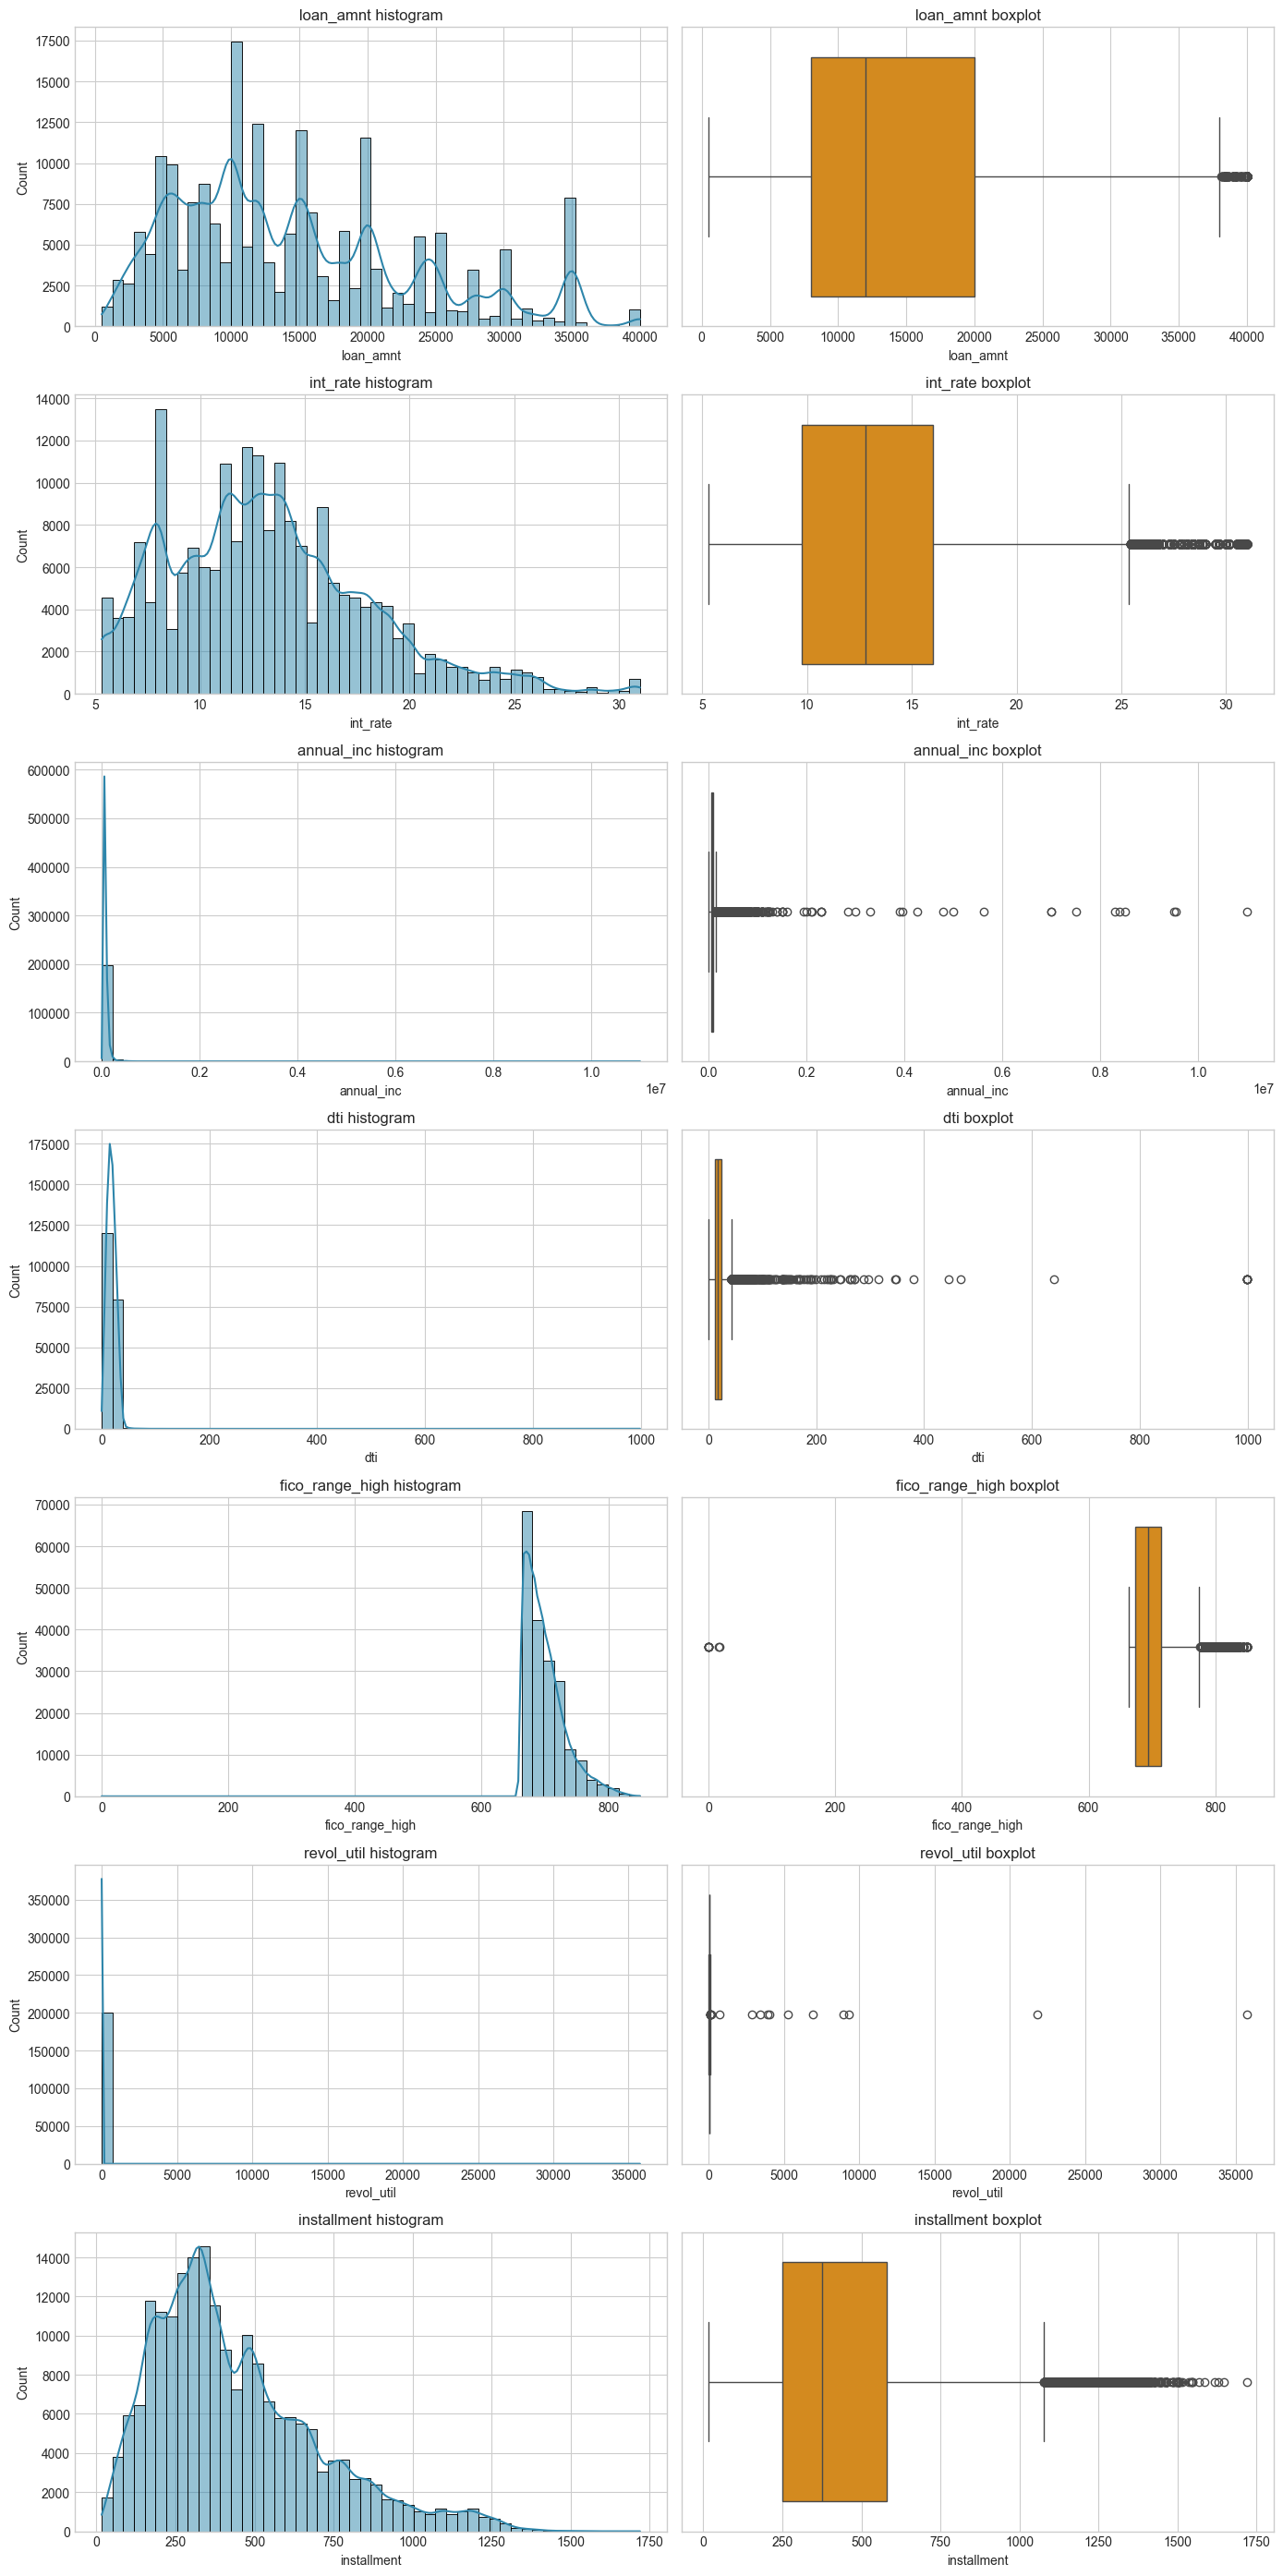

In [8]:
sample_cap = 200000
fraction = min(1.0, sample_cap / max(analysis_count, 1))
numeric_sample_pdf = numeric_df.sample(False, fraction, seed=42).toPandas()

plot_cols = list(existing_numeric.keys())
if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = np.array([axes])

    for i, col_name in enumerate(plot_cols):
        sns.histplot(numeric_sample_pdf[col_name].dropna(), bins=50, kde=True, ax=axes[i, 0], color="#2E86AB")
        axes[i, 0].set_title(f"{col_name} histogram")

        sns.boxplot(x=numeric_sample_pdf[col_name].dropna(), ax=axes[i, 1], color="#F18F01")
        axes[i, 1].set_title(f"{col_name} boxplot")

    plt.tight_layout()
    plt.show()
else:
    print("No requested numerical columns are available in the dataframe.")

Risk interpretation notes for numerical variables:
- Higher `int_rate`, `dti`, and `revol_util` are typically associated with elevated default risk.
- Lower `fico_range_high` usually indicates weaker creditworthiness.
- Extreme `loan_amnt` and `installment` values can create repayment stress, especially at lower income levels.

## 4) Categorical Variable Analysis

Requested variables:
- home_ownership
- purpose
- verification_status
- term
- emp_length


Column: home_ownership
Frequency table:
+--------------+------+
|home_ownership|count |
+--------------+------+
|MORTGAGE      |674903|
|RENT          |543891|
|OWN           |147526|
|ANY           |304   |
|OTHER         |144   |
|NONE          |48    |
+--------------+------+

Default rate by category:
+--------------+------+-------------------+
|home_ownership|count |default_rate       |
+--------------+------+-------------------+
|MORTGAGE      |674903|0.18351526071153929|
|RENT          |543891|0.2455344912859378 |
|OWN           |147526|0.22069330151973213|
|ANY           |304   |0.24342105263157895|
|OTHER         |144   |0.1875             |
|NONE          |48    |0.14583333333333334|
+--------------+------+-------------------+



c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


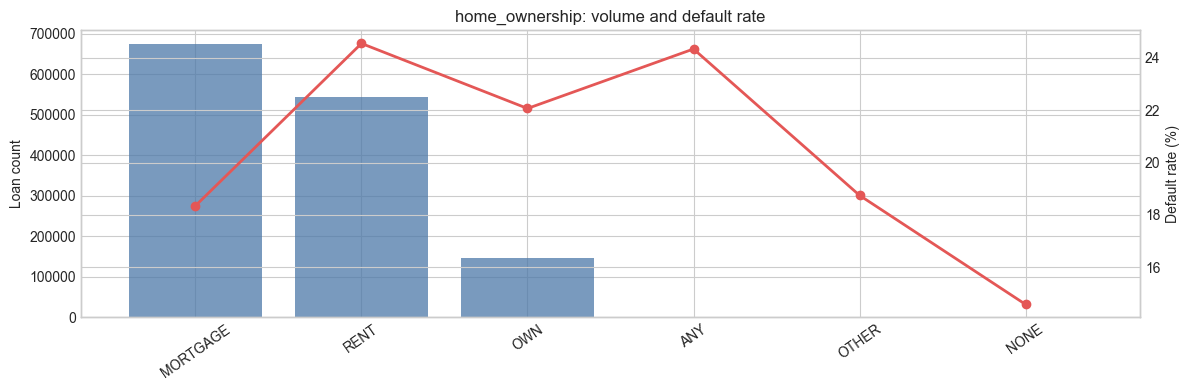


Column: purpose
Frequency table:
+-----------------------------------------------------------------------------------------------------------------------------------+------+
|purpose                                                                                                                            |count |
+-----------------------------------------------------------------------------------------------------------------------------------+------+
|debt_consolidation                                                                                                                 |792741|
|credit_card                                                                                                                        |299260|
|home_improvement                                                                                                                   |88932 |
|other                                                                                                                  

c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


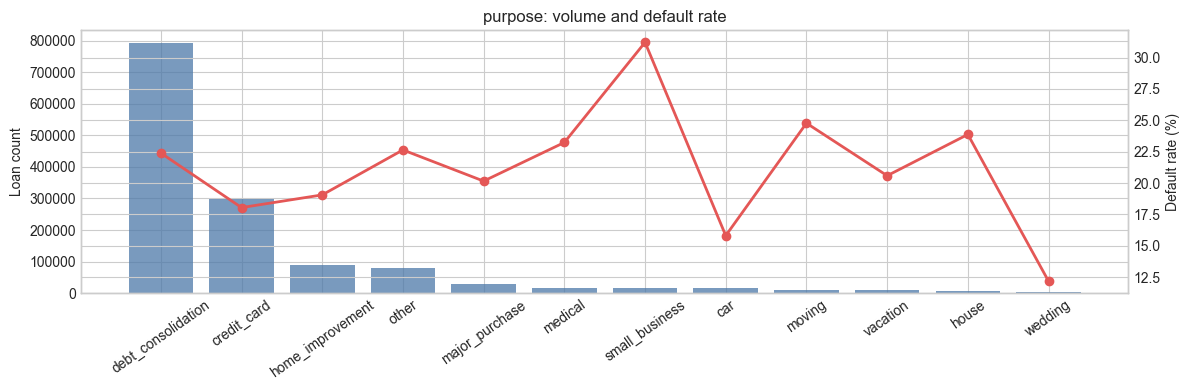


Column: verification_status
Frequency table:
+-------------------+------+
|verification_status|count |
+-------------------+------+
|Source Verified    |530337|
|Verified           |425051|
|Not Verified       |411428|
+-------------------+------+

Default rate by category:
+-------------------+------+-------------------+
|verification_status|count |default_rate       |
+-------------------+------+-------------------+
|Source Verified    |530337|0.22305816867388095|
|Verified           |425051|0.25057463692592186|
|Not Verified       |411428|0.15862313697657912|
+-------------------+------+-------------------+



c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


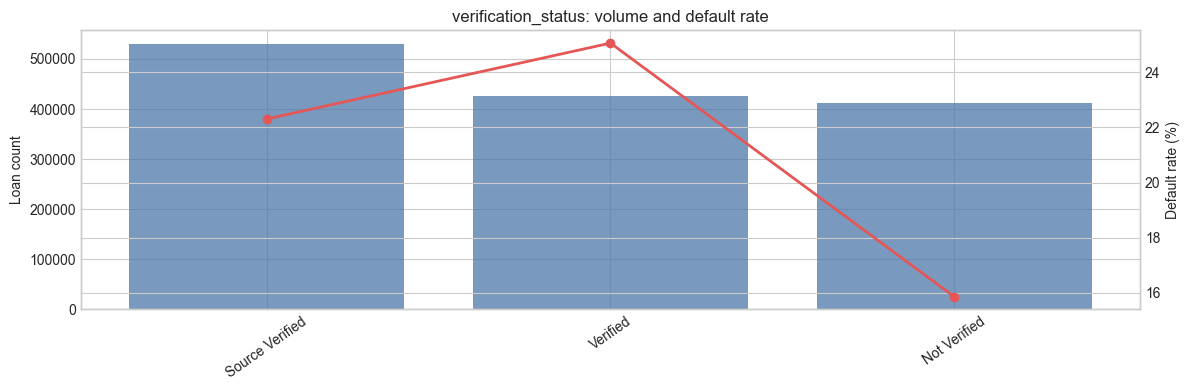


Column: term
Frequency table:
+----------+-------+
|term      |count  |
+----------+-------+
| 36 months|1033242|
| 60 months|333574 |
+----------+-------+

Default rate by category:
+----------+-------+-------------------+
|term      |count  |default_rate       |
+----------+-------+-------------------+
| 36 months|1033242|0.17009664725204743|
| 60 months|333574 |0.3426945745171986 |
+----------+-------+-------------------+



c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


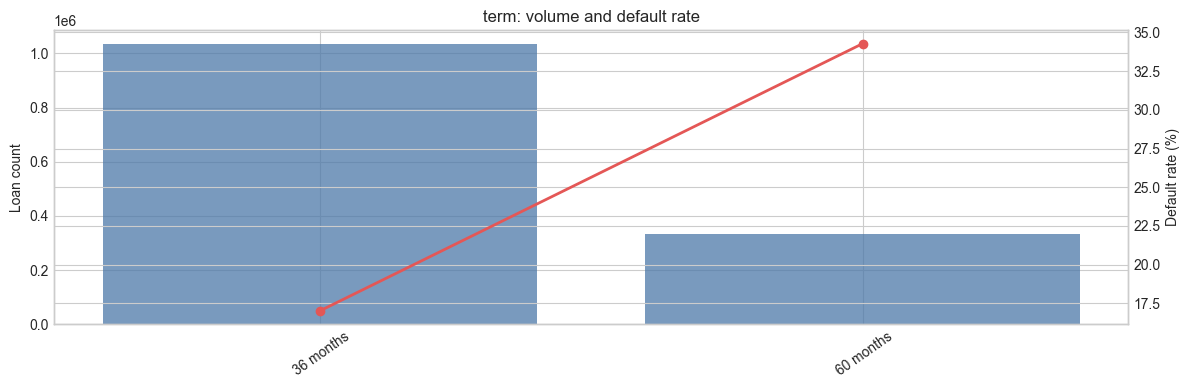


Column: emp_length
Frequency table:
+----------+------+
|emp_length|count |
+----------+------+
|10+ years |448782|
|2 years   |123713|
|< 1 year  |110094|
|3 years   |109396|
|1 year    |89937 |
|5 years   |85473 |
|4 years   |81971 |
|NULL      |80367 |
|6 years   |63654 |
|8 years   |61459 |
|7 years   |60395 |
|9 years   |51575 |
+----------+------+

Default rate by category:
+----------+------+-------------------+
|emp_length|count |default_rate       |
+----------+------+-------------------+
|10+ years |448782|0.19974063130874234|
|2 years   |123713|0.21084283785859206|
|< 1 year  |110094|0.21994840772430832|
|3 years   |109396|0.21285056126366594|
|1 year    |89937 |0.21838620367590647|
|5 years   |85473 |0.208416692990769  |
|4 years   |81971 |0.2112332410242647 |
|NULL      |80367 |0.28601291574900145|
|6 years   |63654 |0.20518741948659944|
|8 years   |61459 |0.2092126458289266 |
|7 years   |60395 |0.20516599056213264|
|9 years   |51575 |0.20891904992729035|
+----------+----

c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


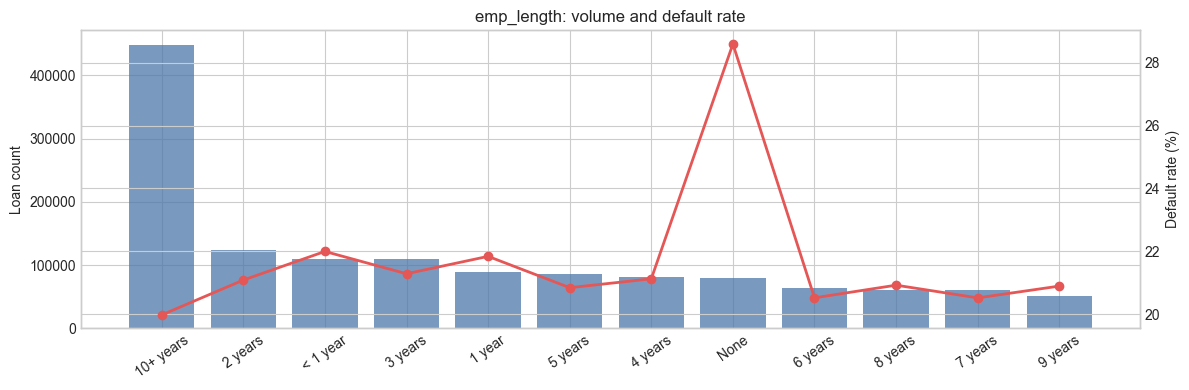

In [9]:
categorical_cols = ["home_ownership", "purpose", "verification_status", "term", "emp_length"]
available_cat_cols = [c for c in categorical_cols if c in analysis_df.columns]

for c in available_cat_cols:
    print("\n" + "=" * 100)
    print(f"Column: {c}")

    freq_df = analysis_df.groupBy(c).count().orderBy(F.desc("count"))
    risk_df = (
        analysis_df.groupBy(c)
        .agg(
            F.count("*").alias("count"),
            F.avg(TARGET_COL).alias("default_rate")
        )
        .orderBy(F.desc("count"))
    )

    print("Frequency table:")
    freq_df.show(15, truncate=False)

    print("Default rate by category:")
    risk_df.show(15, truncate=False)

    plot_df = risk_df.limit(12).toPandas()
    if plot_df.empty:
        continue

    plot_df[c] = plot_df[c].astype(str)
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.bar(plot_df[c], plot_df["count"], color="#4C78A8", alpha=0.75)
    ax1.set_ylabel("Loan count")
    ax1.tick_params(axis="x", rotation=35)

    ax2 = ax1.twinx()
    ax2.plot(plot_df[c], plot_df["default_rate"] * 100, color="#E45756", marker="o", linewidth=2)
    ax2.set_ylabel("Default rate (%)")

    plt.title(f"{c}: volume and default rate")
    plt.tight_layout()
    plt.show()

Business insight prompts:
- Categories with both high volume and high default rate deserve stricter underwriting policies.
- `verification_status` differences can reveal documentation quality impact on risk.
- `term` and `emp_length` interactions are often useful for risk segmentation.

## 5) Correlation Analysis

This section builds a correlation matrix, a heatmap, target correlations, and checks multicollinearity.

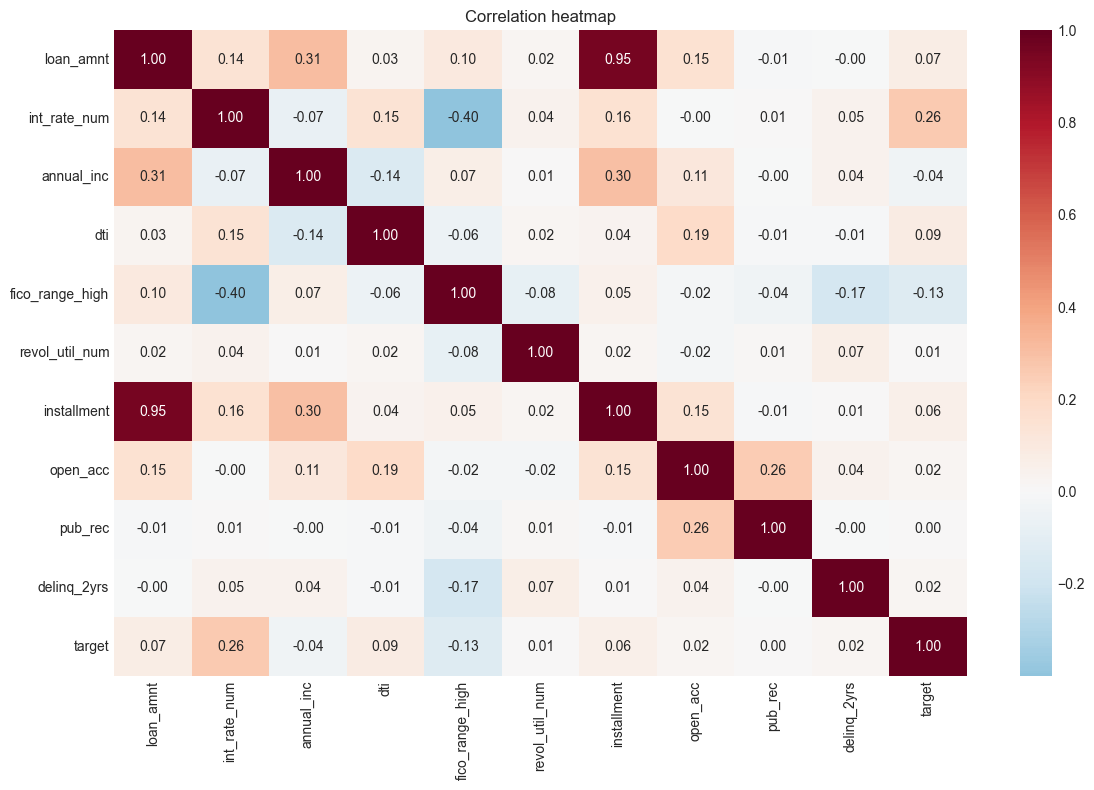

Top features correlated with target:
        feature  corr_with_target  abs_corr
   int_rate_num          0.263243  0.263243
fico_range_high         -0.128047  0.128047
            dti          0.085159  0.085159
      loan_amnt          0.071720  0.071720
    installment          0.056848  0.056848
     annual_inc         -0.039626  0.039626
       open_acc          0.022232  0.022232
    delinq_2yrs          0.019786  0.019786
 revol_util_num          0.007572  0.007572
        pub_rec          0.003889  0.003889

Potential multicollinearity pairs (|corr| >= 0.75):
feature_1   feature_2     corr
loan_amnt installment 0.953048


In [10]:
corr_features = [
    "loan_amnt", "int_rate_num", "annual_inc", "dti", "fico_range_high",
    "revol_util_num", "installment", "open_acc", "pub_rec", "delinq_2yrs", TARGET_COL
]
corr_features = [c for c in corr_features if c in analysis_df.columns]

corr_df = analysis_df.select(*[F.col(c).cast("double").alias(c) for c in corr_features]).dropna(subset=[TARGET_COL])

fill_map = {}
for c in corr_features:
    if c == TARGET_COL:
        continue
    q = corr_df.approxQuantile(c, [0.5], 0.01)
    fill_map[c] = float(q[0]) if q else 0.0
corr_df = corr_df.na.fill(fill_map).persist(StorageLevel.MEMORY_AND_DISK)

assembler = VectorAssembler(inputCols=corr_features, outputCol="corr_vector", handleInvalid="skip")
vec_df = assembler.transform(corr_df).select("corr_vector")
corr_matrix = Correlation.corr(vec_df, "corr_vector", "pearson").head()[0].toArray()
corr_pdf = pd.DataFrame(corr_matrix, index=corr_features, columns=corr_features)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_pdf, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

target_corr_rows = []
for c in corr_features:
    if c == TARGET_COL:
        continue
    target_corr_rows.append((c, corr_df.stat.corr(c, TARGET_COL)))

target_corr_pdf = pd.DataFrame(target_corr_rows, columns=["feature", "corr_with_target"])
target_corr_pdf["abs_corr"] = target_corr_pdf["corr_with_target"].abs()
target_corr_pdf = target_corr_pdf.sort_values("abs_corr", ascending=False)
print("Top features correlated with target:")
print(target_corr_pdf.to_string(index=False))

multicollinearity_pairs = []
core_features = [c for c in corr_features if c != TARGET_COL]
for i, c1 in enumerate(core_features):
    for j in range(i + 1, len(core_features)):
        c2 = core_features[j]
        val = corr_pdf.loc[c1, c2]
        if abs(val) >= 0.75:
            multicollinearity_pairs.append((c1, c2, val))

if multicollinearity_pairs:
    multi_pdf = pd.DataFrame(multicollinearity_pairs, columns=["feature_1", "feature_2", "corr"])
    print("\nPotential multicollinearity pairs (|corr| >= 0.75):")
    print(multi_pdf.to_string(index=False))
else:
    print("\nNo multicollinearity pair exceeded |corr| >= 0.75 in selected features.")

Interpretation notes:
- Strongly correlated features can destabilize linear models and inflate variance.
- If two features are near-duplicates, keep the one with better business interpretability.
- Features with stronger absolute target correlation are natural candidates for baseline models.

## 6) Time Series Analysis

This section converts `issue_d` into a date and analyzes yearly/monthly trends in loan volume and default behavior.

c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


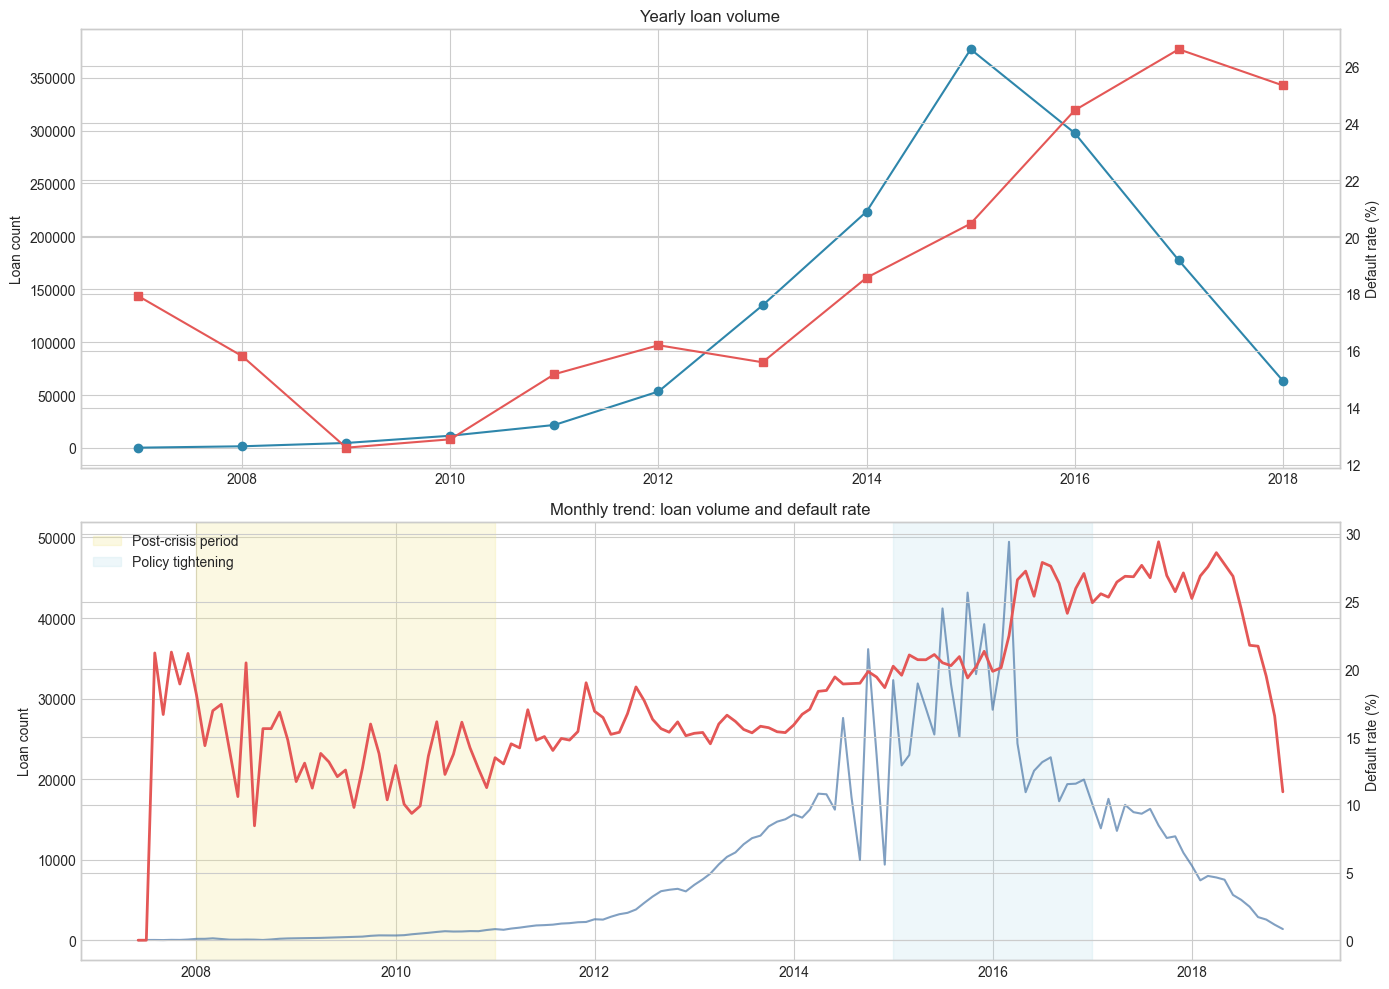

In [11]:
ts_df = (
    analysis_df
    .withColumn("issue_date", F.to_date(F.col("issue_d"), "MMM-yyyy"))
    .filter(F.col("issue_date").isNotNull())
    .select("issue_date", TARGET_COL)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

yearly_df = (
    ts_df.groupBy(F.year("issue_date").alias("year"))
    .agg(
        F.count("*").alias("loan_count"),
        F.avg(TARGET_COL).alias("default_rate")
    )
    .orderBy("year")
)

monthly_df = (
    ts_df.groupBy(F.date_trunc("month", F.col("issue_date")).alias("month"))
    .agg(
        F.count("*").alias("loan_count"),
        F.avg(TARGET_COL).alias("default_rate")
    )
    .orderBy("month")
)

yearly_pdf = yearly_df.toPandas()
monthly_pdf = monthly_df.toPandas()

if not yearly_pdf.empty:
    yearly_pdf["default_rate_pct"] = yearly_pdf["default_rate"] * 100
if not monthly_pdf.empty:
    monthly_pdf["default_rate_pct"] = monthly_pdf["default_rate"] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

if not yearly_pdf.empty:
    axes[0].plot(yearly_pdf["year"], yearly_pdf["loan_count"], marker="o", color="#2E86AB")
    axes[0].set_title("Yearly loan volume")
    axes[0].set_ylabel("Loan count")

    ax0_twin = axes[0].twinx()
    ax0_twin.plot(yearly_pdf["year"], yearly_pdf["default_rate_pct"], marker="s", color="#E45756")
    ax0_twin.set_ylabel("Default rate (%)")

if not monthly_pdf.empty:
    axes[1].plot(monthly_pdf["month"], monthly_pdf["loan_count"], color="#4C78A8", alpha=0.7)
    axes[1].set_title("Monthly trend: loan volume and default rate")
    axes[1].set_ylabel("Loan count")

    ax1_twin = axes[1].twinx()
    ax1_twin.plot(monthly_pdf["month"], monthly_pdf["default_rate_pct"], color="#E45756", linewidth=2)
    ax1_twin.set_ylabel("Default rate (%)")

    axes[1].axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2010-12-31"), color="#f0e68c", alpha=0.25, label="Post-crisis period")
    axes[1].axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2016-12-31"), color="#add8e6", alpha=0.20, label="Policy tightening")
    axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

Time-series insight prompts:
- Changes in default trend by period may reflect macro-financial shocks and policy cycles.
- Sudden growth in loan volume without stable default rates can signal changing underwriting quality.
- Year-over-year shift in rate regime should be incorporated through temporal features in modeling.

## 7) Risk Analysis

Relationships analyzed:
- fico score vs default
- income vs default
- interest rate vs default
- loan amount vs default
- dti vs default

Quantile-based risk curves are used for robust segmentation.

c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib

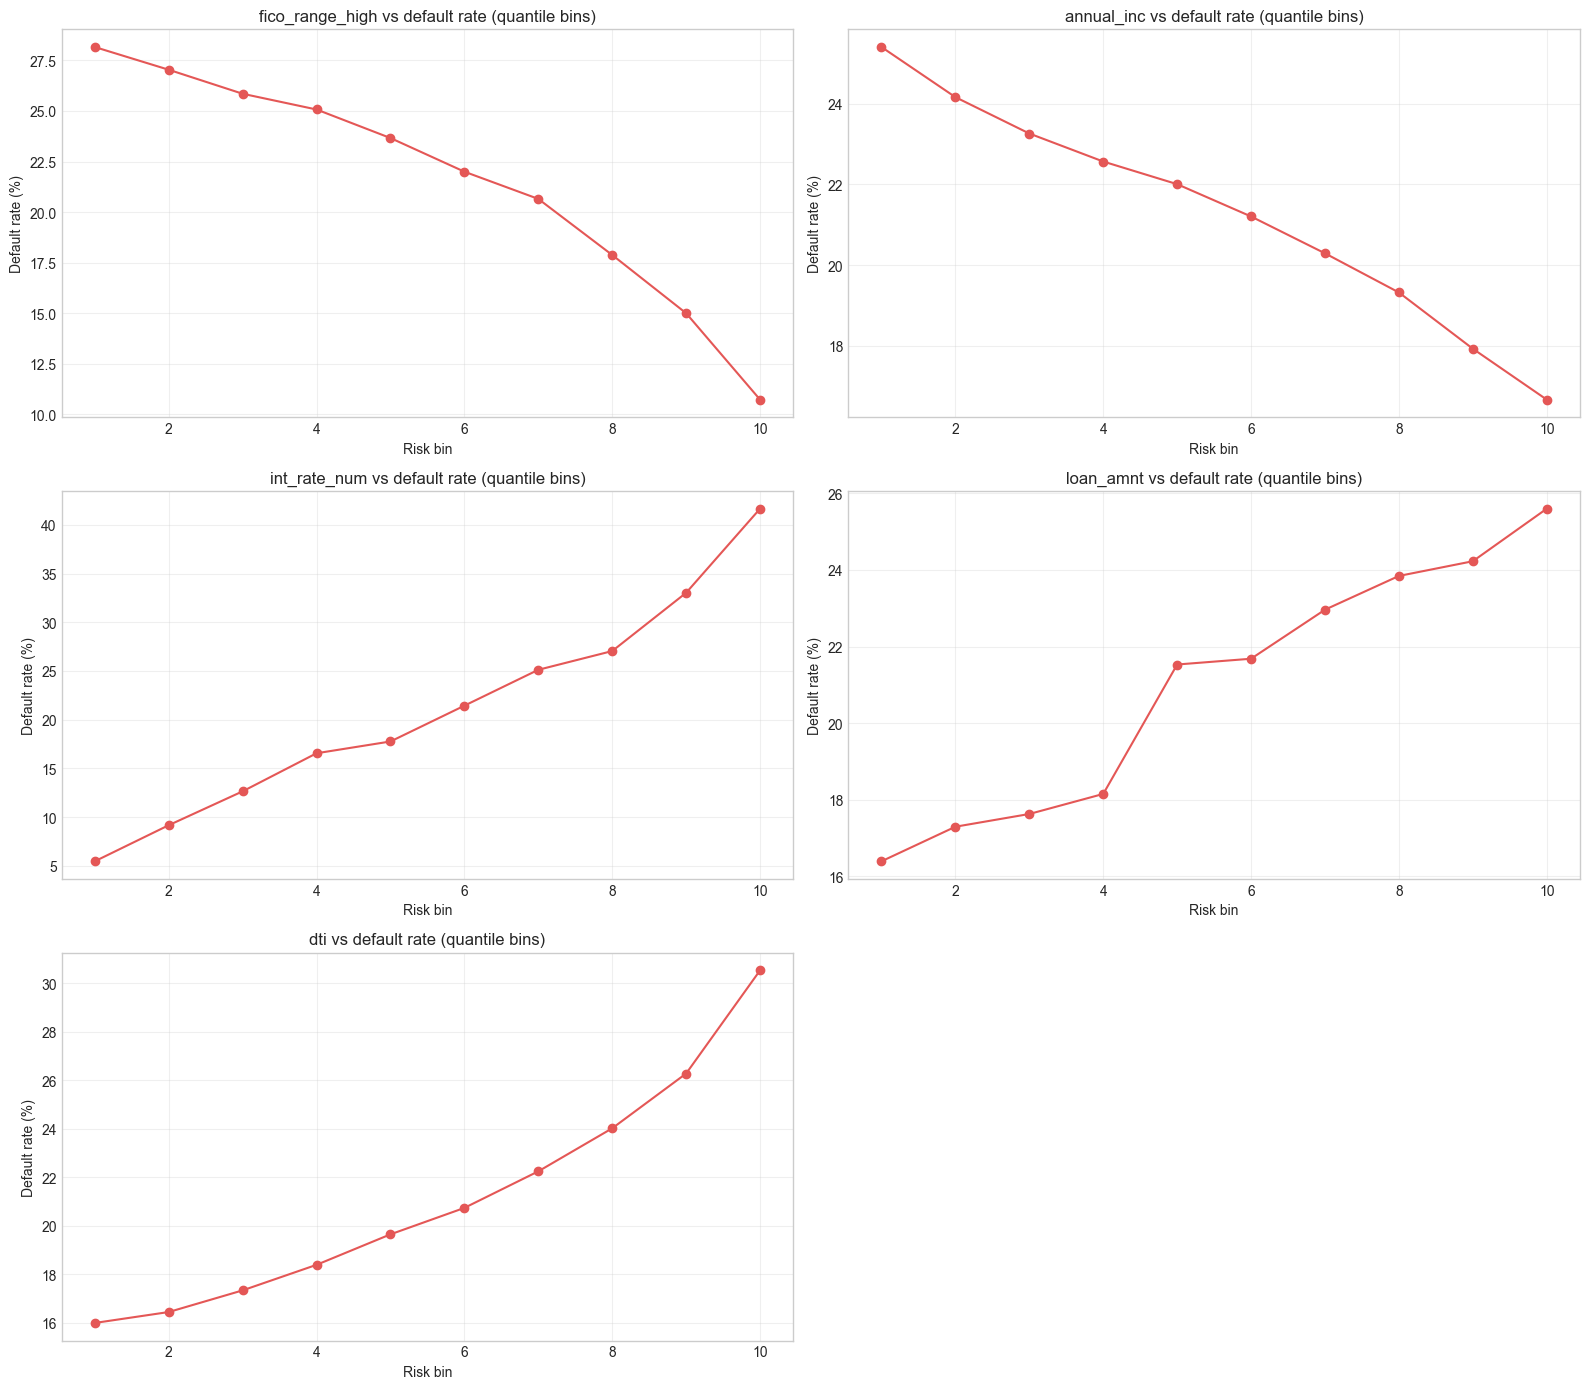

+------------+-------+-------------------+-----------------+------------------+
|risk_segment|n_loans|default_rate       |avg_income       |avg_loan_amnt     |
+------------+-------+-------------------+-----------------+------------------+
|High Risk   |446528 |0.30964239644546365|66752.79719063532|15463.924826662605|
|Medium Risk |703045 |0.1882070137757896 |77057.01325943577|13767.26767134394 |
|Low Risk    |217243 |0.0896829817301363 |93220.97732419455|14636.167448433322|
+------------+-------+-------------------+-----------------+------------------+



c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


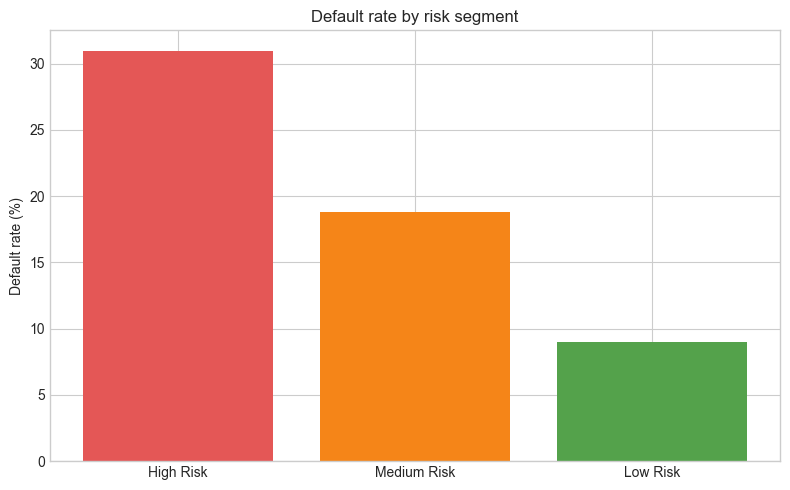

In [13]:
risk_df = analysis_df.select(
    F.col("fico_range_high").cast("double").alias("fico_range_high"),
    F.col("annual_inc").cast("double").alias("annual_inc"),
    F.col("int_rate_num").cast("double").alias("int_rate_num"),
    F.col("loan_amnt").cast("double").alias("loan_amnt"),
    F.col("dti").cast("double").alias("dti"),
    F.col(TARGET_COL).cast("double").alias(TARGET_COL)
).dropna(subset=[TARGET_COL]).persist(StorageLevel.MEMORY_AND_DISK)

def quantile_curve(df_input, feature_col, n_bins=10):
    quantiles = df_input.approxQuantile(feature_col, [i / n_bins for i in range(n_bins + 1)], 0.01)
    splits = sorted(set(quantiles))
    if len(splits) < 3:
        return None
    splits[0] = float("-inf")
    splits[-1] = float("inf")

    bucket_col = f"{feature_col}_bucket"
    bucketizer = Bucketizer(splits=splits, inputCol=feature_col, outputCol=bucket_col, handleInvalid="keep")
    bucketed = bucketizer.transform(df_input.select(feature_col, TARGET_COL).dropna())

    return (
        bucketed.groupBy(bucket_col)
        .agg(
            F.min(feature_col).alias("min_value"),
            F.max(feature_col).alias("max_value"),
            F.count("*").alias("n_obs"),
            F.avg(TARGET_COL).alias("default_rate")
        )
        .orderBy(bucket_col)
    )

risk_features = ["fico_range_high", "annual_inc", "int_rate_num", "loan_amnt", "dti"]
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature_name in enumerate(risk_features):
    ax = axes[i]
    curve_df = quantile_curve(risk_df, feature_name, n_bins=10)

    if curve_df is None:
        ax.set_title(f"{feature_name}: insufficient variance")
        ax.axis("off")
        continue

    curve_pdf = curve_df.toPandas()
    ax.plot(curve_pdf.index + 1, curve_pdf["default_rate"] * 100, marker="o", color="#E45756")
    ax.set_title(f"{feature_name} vs default rate (quantile bins)")
    ax.set_xlabel("Risk bin")
    ax.set_ylabel("Default rate (%)")
    ax.grid(alpha=0.3)

for j in range(len(risk_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

segment_df = (
    risk_df
    .withColumn(
        "risk_segment",
        F.when(
            (F.col("fico_range_high") < 660) |
            (F.col("dti") > 25) |
            (F.col("int_rate_num") > 18),
            F.lit("High Risk")
        ).when(
            (F.col("fico_range_high") < 700) |
            (F.col("dti") > 18) |
            (F.col("int_rate_num") > 13),
            F.lit("Medium Risk")
        ).otherwise(F.lit("Low Risk"))
    )
)

segment_summary = (
    segment_df.groupBy("risk_segment")
    .agg(
        F.count("*").alias("n_loans"),
        F.avg(TARGET_COL).alias("default_rate"),
        F.avg("annual_inc").alias("avg_income"),
        F.avg("loan_amnt").alias("avg_loan_amnt")
    )
    .orderBy(F.desc("default_rate"))
)
segment_summary.show(truncate=False)

segment_pdf = segment_summary.toPandas()
if not segment_pdf.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(segment_pdf["risk_segment"], segment_pdf["default_rate"] * 100, color=["#E45756", "#F58518", "#54A24B"])
    plt.ylabel("Default rate (%)")
    plt.title("Default rate by risk segment")
    plt.tight_layout()
    plt.show()

## 8) EDA Executive Summary

Use this section directly in presentation output:

### Most risky customer profile
- Lower FICO range, high DTI, high interest rate, high utilization, unstable employment.

### Strong candidate features
- `int_rate_num`, `dti`, `fico_range_high`, `revol_util_num`, `annual_inc`, `installment`, `purpose`, `verification_status`.

### Data quality issues
- High-missing columns require threshold-based deletion or robust imputation.
- Percentage fields (`int_rate`, `revol_util`) require explicit numeric parsing.
- Category cardinality and inconsistent text formats should be standardized.

### Imbalance status
- GOOD/BAD ratio should be monitored before training.
- Use class weighting and potentially balanced sampling in model stage.

### Pre-modeling checklist
1. Remove leakage columns.
2. Finalize missing-data strategy by feature family.
3. Build encoded feature pipeline with reproducible Spark ML stages.
4. Apply temporal split and evaluate model stability by period.